In [33]:
import jax
import jax.numpy as jnp
from tensorflow_probability.substrates import jax as tfp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from diffrax import diffeqsolve, ControlTerm, Dopri5, Heun, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, WeaklyDiagonalControlTerm
import jax.random as jr
import lineax as lx
from pqm import pqm_chi2
import torch
from scipy.stats import norm, chi2, uniform

JAX_DISABLE_JIT=1
jax.config.update("jax_enable_x64", True)

In [34]:
tfd = tfp.distributions
tfb = tfp.bijectors
tfpk = tfp.math.psd_kernels

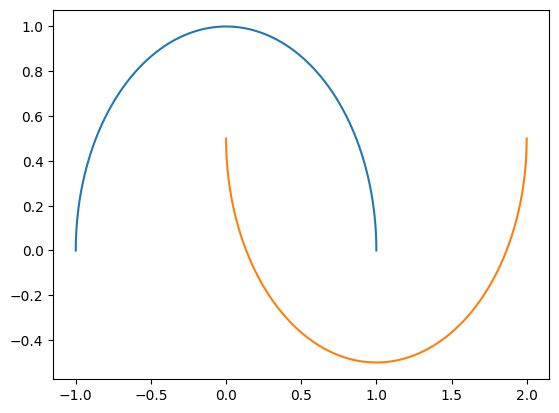

In [35]:
# This code is taken from make_moons in sklearn
resolution = 2000
outer_circ_x = np.cos(np.linspace(0, np.pi, resolution))
outer_circ_y = np.sin(np.linspace(0, np.pi, resolution))
inner_circ_x = 1 - np.cos(np.linspace(0, np.pi, resolution))
inner_circ_y = 1 - np.sin(np.linspace(0, np.pi, resolution)) - .5

X = np.append(outer_circ_x, inner_circ_x)
Y = np.append(outer_circ_y, inner_circ_y)
coords = np.vstack([X,Y])

# This is the Two Moon Distribution
'''
The way the two moon distribution is by defining a Mixture of Gaussian with varying width
'''
plot(outer_circ_x,outer_circ_y)
plot(inner_circ_x,inner_circ_y)

Task:
1. Implement a basic score based model and use it on the Two Moon Distribution
- Use JAX & Diffrax Libraries --> Minimal or no use of PyTorch
- The score function is analytical here


Two processes
1) Foward SDE  | $dX = f(x,t) + g(t)dW$
2) Reverse SDE | $dX = [f(x,t) - g^2(t) \nabla_x log p_t(x)] dt + g(t)dw$


Need to Implement a Varaiance Perserving SDE
$dx = -\frac{1}{2} \Beta(t)x dt + \sqrt(\Beta(t))dw$

Need to Implement a Varience Exploding SDE
$dx = \sqrt{\frac{d[\sigma^2 (t)]}{dt}}dw$

Can use Tweedie's I think: ∇_x log p_t(x) = -(x - E[μ_k | x]) / s²(t)

The Setup for this will be
Start from the Two Moon Distribution and Forward Process it which is effectively injecting noise until the data is all noise. At this stage you are learning the score function but we don't need to worry about this since the Two Moon Distribution is a Mixture of Gaussians (with sigma being the width of the Gaussians) so we can analytically write the score function

Then you start from noise and then denoise step by step until t~0 and thus get samples using the analytical score function

In [36]:
def run_pqm(sample_A, sample_B):
    all_data = torch.cat([torch.Tensor(sample_A), torch.Tensor(sample_B)], dim=0).detach().numpy()
    np.random.shuffle(all_data)

    x_samples = torch.tensor(all_data[:len(all_data)//2], device = 'mps')
    y_samples = torch.tensor(all_data[len(all_data)//2:], device = 'mps')

    x_np = x_samples.cpu().numpy()
    y_np = y_samples.cpu().numpy()

    zs = []

    for i in range(1000):
        z = pqm_chi2(x_np, y_np, num_refs=50, gauss_frac=1.0)
        zs += [z]
    return zs

# Define Ideal Chi2 For Plotting
df = 49
mean = df
std = np.sqrt(2 * df)

# Plot range: mean ± 4 standard deviations (captures ~99.99% of distribution)
x_min = max(0, mean - 4 * std)
x_max = mean + 4 * std
ideal_chi2 = np.linspace(x_min, x_max, 500)

# Define the Dataset

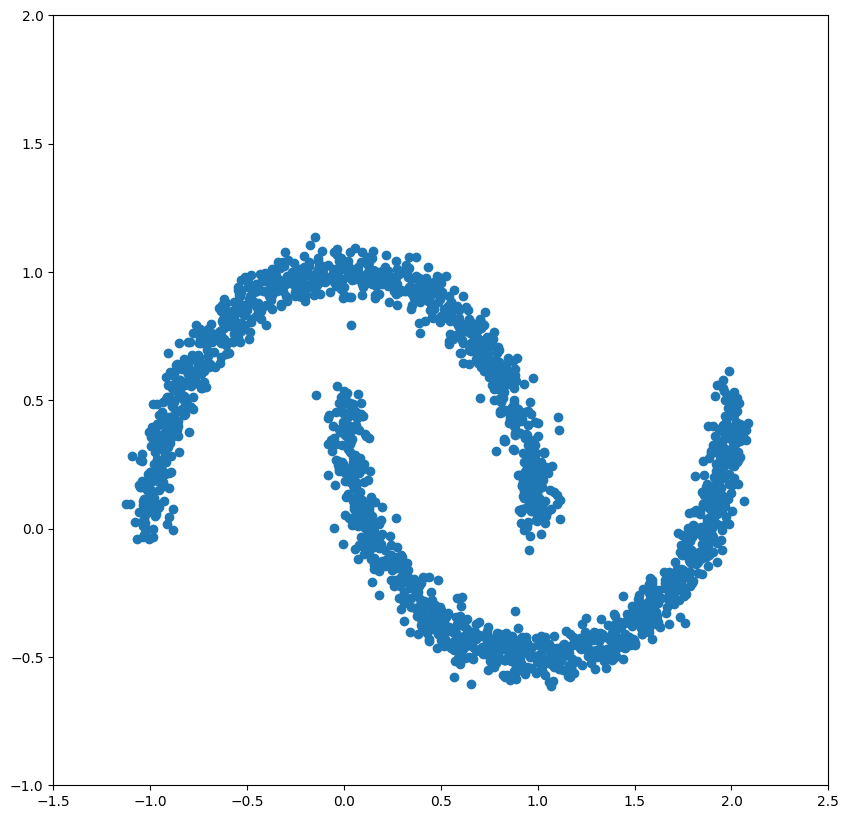

In [37]:
# Data
sigma = 0.05
# We approximate the 2 moons with a large mixture
distribution = tfd.MixtureSameFamily(
    mixture_distribution=tfd.Categorical(probs=np.ones(2*resolution)/resolution/2),
    components_distribution=tfd.MultivariateNormalDiag(loc=coords.T, scale_diag=sigma*np.ones(2))
)

rng_key = jax.random.PRNGKey(seed=0)
samps = distribution.sample(resolution, seed=rng_key)

plt.figure(figsize=[10,10])
plt.scatter(samps[:,0], samps[:,1])
# plt.axis('off');
plt.xlim(-1.5,-1.5+4)
plt.ylim(-1.,-1.+3)
plt.show()

# Variance Perserving (VP) SDE

In [51]:
def beta_noise_schedule(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t

def score_fn(x, t, args):
    # Tweedie Formula 
    beta_min, beta_max = args
    integral_beta = beta_min * t + 0.5 * (beta_max - beta_min) * t**2
    m_t = jnp.exp(-0.5 * integral_beta)
    v_t = 1.0 - jnp.exp(-integral_beta)
    s2  = m_t**2 * sigma**2 + v_t      

    mus       = m_t * jnp.array(coords.T)             
    log_r     = -0.5 * jnp.sum((x - mus)**2, axis=-1) / s2 
    post_mean = jax.nn.softmax(log_r) @ mus 
    return -(x - post_mean) / s2

def drift_fn(t, y, args):
    # -\frac{1}{2} \Beta(t)x
    beta_min, beta_max = args
    return -0.5 * beta_noise_schedule(t, beta_min, beta_max) * y

def diff_coeff(t, y, args):
    beta_min, beta_max = args
    # return jnp.sqrt(beta_noise_schedule(t, beta_min, beta_max))  # plain scalar
    return lx.DiagonalLinearOperator(jnp.full(y.shape[-1], jnp.sqrt(beta_noise_schedule(t, beta_min, beta_max))))

def rev_drift_fn(t, y, args):
    beta_min, beta_max = args
    score = jax.vmap(lambda x: score_fn(x, t, args))(y)
    beta_t = beta_noise_schedule(t, beta_min, beta_max)
    return drift_fn(t, y, args) - beta_t * score

def forward_fn(samples, t0, t1, beta_min, beta_max):
    args = (beta_min, beta_max)
    bm = VirtualBrownianTree(t0=t0, t1=t1, tol=1e-3, shape=samples.shape, key=jr.PRNGKey(2))
    terms = MultiTerm(ODETerm(drift_fn), ControlTerm(diff_coeff, bm))

    solver = Heun()
    saveat = SaveAt(t1=True)

    sol = diffeqsolve(terms, solver, t0, t1, dt0=0.05, y0=samples, saveat=saveat, args=args)
    return sol.ys

def reverse_fn(samples, t0, t1, beta_min, beta_max):
    args = (beta_min, beta_max)
    bm = VirtualBrownianTree(t0=0.0, t1=1.0, tol=1e-3, shape=samples.shape, key=jr.PRNGKey(3))  # always forward bounds
    terms = MultiTerm(ODETerm(rev_drift_fn), ControlTerm(diff_coeff, bm))

    solver = Heun()
    saveat = SaveAt(t1=True)

    sol = diffeqsolve(terms, solver, t0, t1, dt0=-0.005, y0=samples, saveat=saveat, args=args)
    return sol.ys

In [52]:
# Forward Function Setup
# Start from no noise aka t0 = 0.0 and end at noise aka t1 = 1.0
t0 = 0.0
t1 = 1.0
beta_min = 1e-2
beta_max = 20

# result_forward_pass = forward_fn(samps, t0, t1, beta_min, beta_max)
result_forward_pass = forward_fn(samps, t0, t1, beta_min, beta_max)

# Reverse Function Setup
# Start from noise aka t0 = 1.0 and end at no noise aka t1 = 0.0
t0 = 1.0
t1 = 0.0
beta_min = 1e-2
beta_max = 20

noisy_samples = jax.random.normal(jr.PRNGKey(42), shape=(resolution, 2))
result_reverse_pass = reverse_fn(noisy_samples, t0, t1, beta_min, beta_max)

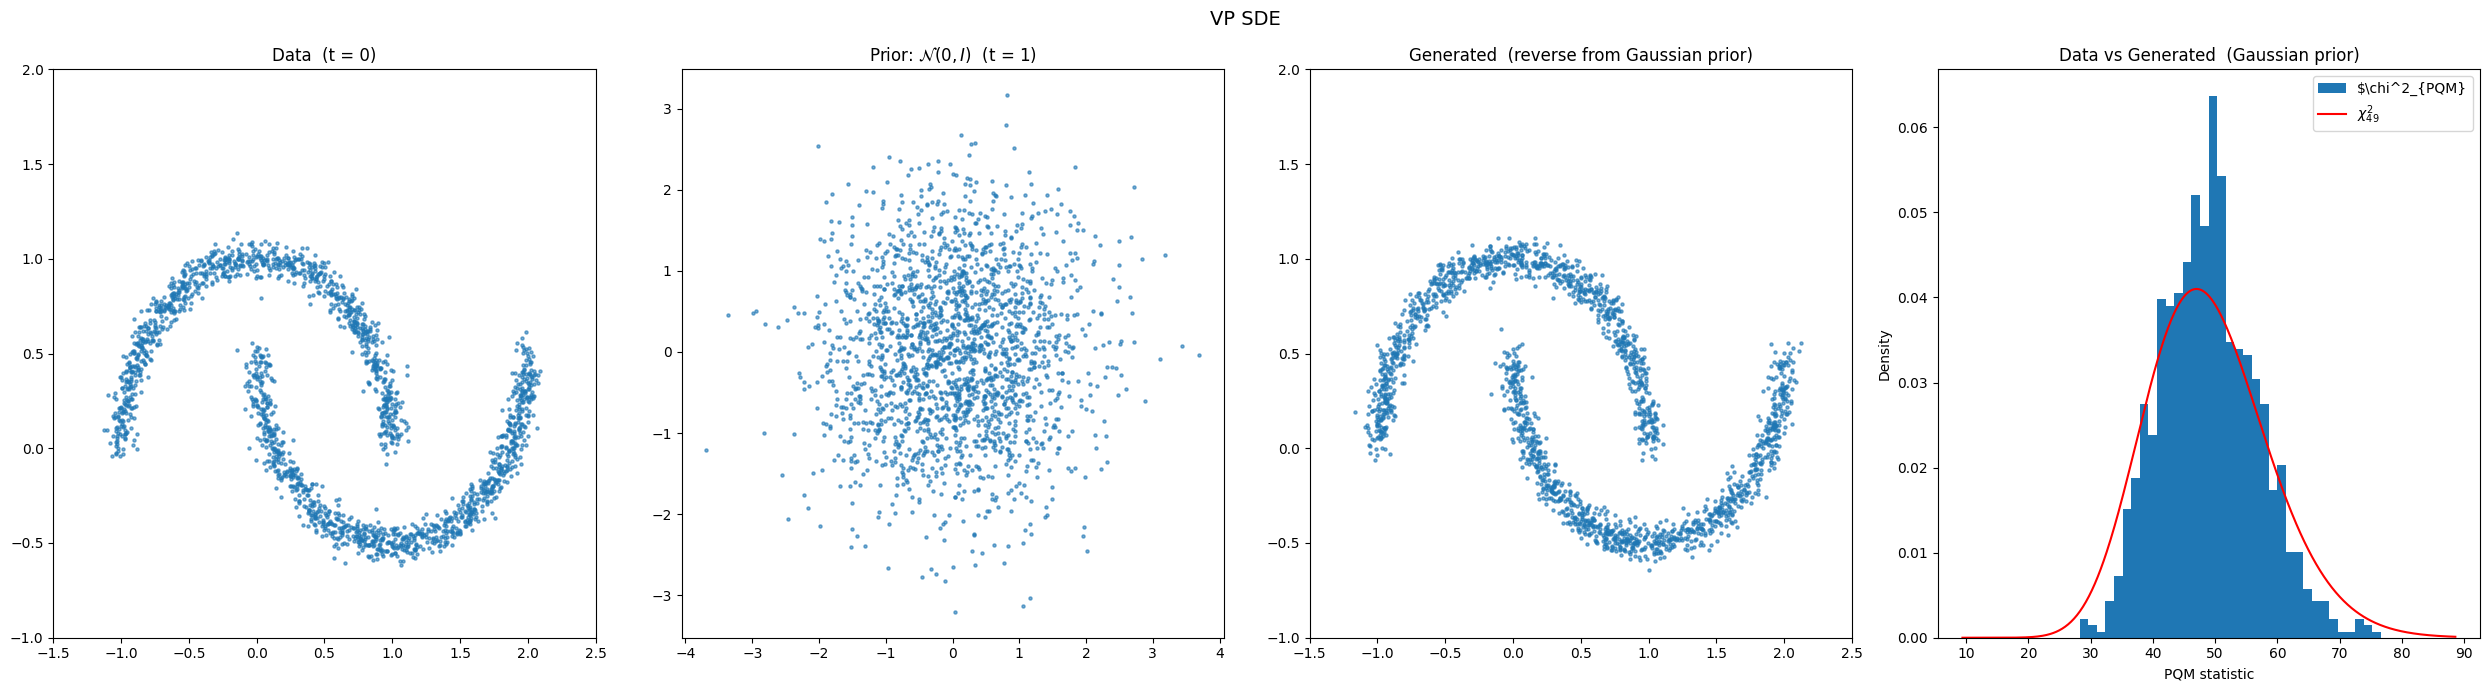

In [53]:
DATA_XLIM = (-1.5, 2.5)
DATA_YLIM = (-1.0, 2.0)

fig, axes = plt.subplots(1, 4, figsize=(25, 7))
zs_result_reverse_pass = run_pqm(samps, result_reverse_pass[0])

# --- Row 0: Pure Gaussian prior → reverse (generative) ---
axes[0].scatter(samps[:, 0], samps[:, 1], s=5, alpha=0.6)
axes[0].set_title("Data  (t = 0)")
axes[0].set_xlim(*DATA_XLIM); axes[0].set_ylim(*DATA_YLIM)

axes[1].scatter(noisy_samples[:, 0], noisy_samples[:, 1], s=5, alpha=0.6)
axes[1].set_title(r"Prior: $\mathcal{N}(0, I)$  (t = 1)")

axes[2].scatter(result_reverse_pass[0][:, 0], result_reverse_pass[0][:, 1], s=5, alpha=0.6)
axes[2].set_title("Generated  (reverse from Gaussian prior)")
axes[2].set_xlim(*DATA_XLIM); axes[2].set_ylim(*DATA_YLIM)

axes[3].hist(zs_result_reverse_pass, bins=35, density=True, label='$\chi^2_{PQM}')
axes[3].plot(ideal_chi2, chi2.pdf(ideal_chi2, df=49), color='red', label=r'$\chi^2_{49}$')
axes[3].set_xlabel('PQM statistic')
axes[3].set_ylabel('Density')
axes[3].set_title('Data vs Generated  (Gaussian prior)')
axes[3].legend()

fig.suptitle("VP SDE", fontsize=14)
plt.tight_layout()
plt.show()

# Variance Exploding (VE) SDE

In [ ]:
def sigma_noise_schedule(t, args):
    sigma_min, sigma_max = args
    return sigma_min * (sigma_max / sigma_min)**(t)

def score_fn(x, t, args):
    # Tweedie Formula 
    sigma_t   = sigma_noise_schedule(t, args)
    s2        = sigma**2 + sigma_t**2

    log_r     = -0.5 * jnp.sum((x - jnp.array(coords.T))**2, axis=-1) / s2
    post_mean = jax.nn.softmax(log_r) @ jnp.array(coords.T)  
    return -(x - post_mean) / s2

def drift_fn(t, y, args):
    # 0 here
    return jnp.zeros_like(y)

def diff_coeff(t, y, args):
    # \sqrt{\frac{d[\sigma^2 (t)]}{dt}}
    # 2σ²(t) * log(σ_max/σ_min) = σ(t) * sqrt(2 * log(σ_max / σ_min)
    sigma_min, sigma_max = args
    rhs = sigma_noise_schedule(t, args) * jnp.sqrt(2 * jnp.log(sigma_max / sigma_min))
    return lx.DiagonalLinearOperator(jnp.full(y.shape[-1], rhs))

def rev_drift_fn(t, y, args):
    # $dX = [f(x,t) - g^2(t) \nabla_x log p_t(x)] dt + g(t)dw$
    # f(x,t) = 0
    # g^2(t) --> 2 \sigma^2(t) log(\frac{\sigma_{\text{max}}}{\sigma_{\text{min}}})
    sigma_min, sigma_max = args
    score = jax.vmap(lambda x: score_fn(x, t, args))(y)
    drift_term = 2 * sigma_noise_schedule(t, args)**2 * jnp.log(sigma_max / sigma_min)
    return drift_fn(t, y, args) - drift_term * score

def forward_fn(t0, t1, samples, sigma_min, sigma_max):
    args = (sigma_min, sigma_max)
    bm = VirtualBrownianTree(t0=t0, t1=t1, tol=1e-3, shape=samples.shape, key=jr.PRNGKey(2))
    terms = MultiTerm(ODETerm(drift_fn), ControlTerm(diff_coeff, bm))

    solver = Heun()
    saveat = SaveAt(t1=True)

    sol = diffeqsolve(terms, solver, t0, t1, dt0=0.05, y0=samples, saveat=saveat, args = args)
    return sol.ys

def reverse_fn(samples, t0, t1, sigma_min, sigma_max):
    args = (sigma_min, sigma_max)
    bm = VirtualBrownianTree(t0=0.0, t1=1.0, tol=1e-3, shape=samples.shape, key=jr.PRNGKey(3))
    terms = MultiTerm(ODETerm(rev_drift_fn), ControlTerm(diff_coeff, bm))

    solver = Heun()
    saveat = SaveAt(t1=True)

    sol = diffeqsolve(terms, solver, t0, t1, dt0=-0.005, y0=samples, saveat=saveat, args=args)
    return sol.ys

In [55]:
sigma_min = 1e-2
sigma_max = 50

# Forward Function Setup
# Start from no noise aka t0 = 0.0 and end at noise aka t1 = 1.0
t0 = 0.0
t1 = 1.0
result_forward_pass = forward_fn(t0, t1, samps, sigma_min, sigma_max)

# Reverse Function Setup
# Start from noise aka t0 = 1.0 and end at no noise aka t1 = 0.0
t0 = 1.0
t1 = 0.0
noisy_samples       = jax.random.normal(jr.PRNGKey(42), shape=(resolution, 2)) * sigma_max
result_reverse_pass = reverse_fn(noisy_samples, t0, t1, sigma_min, sigma_max)

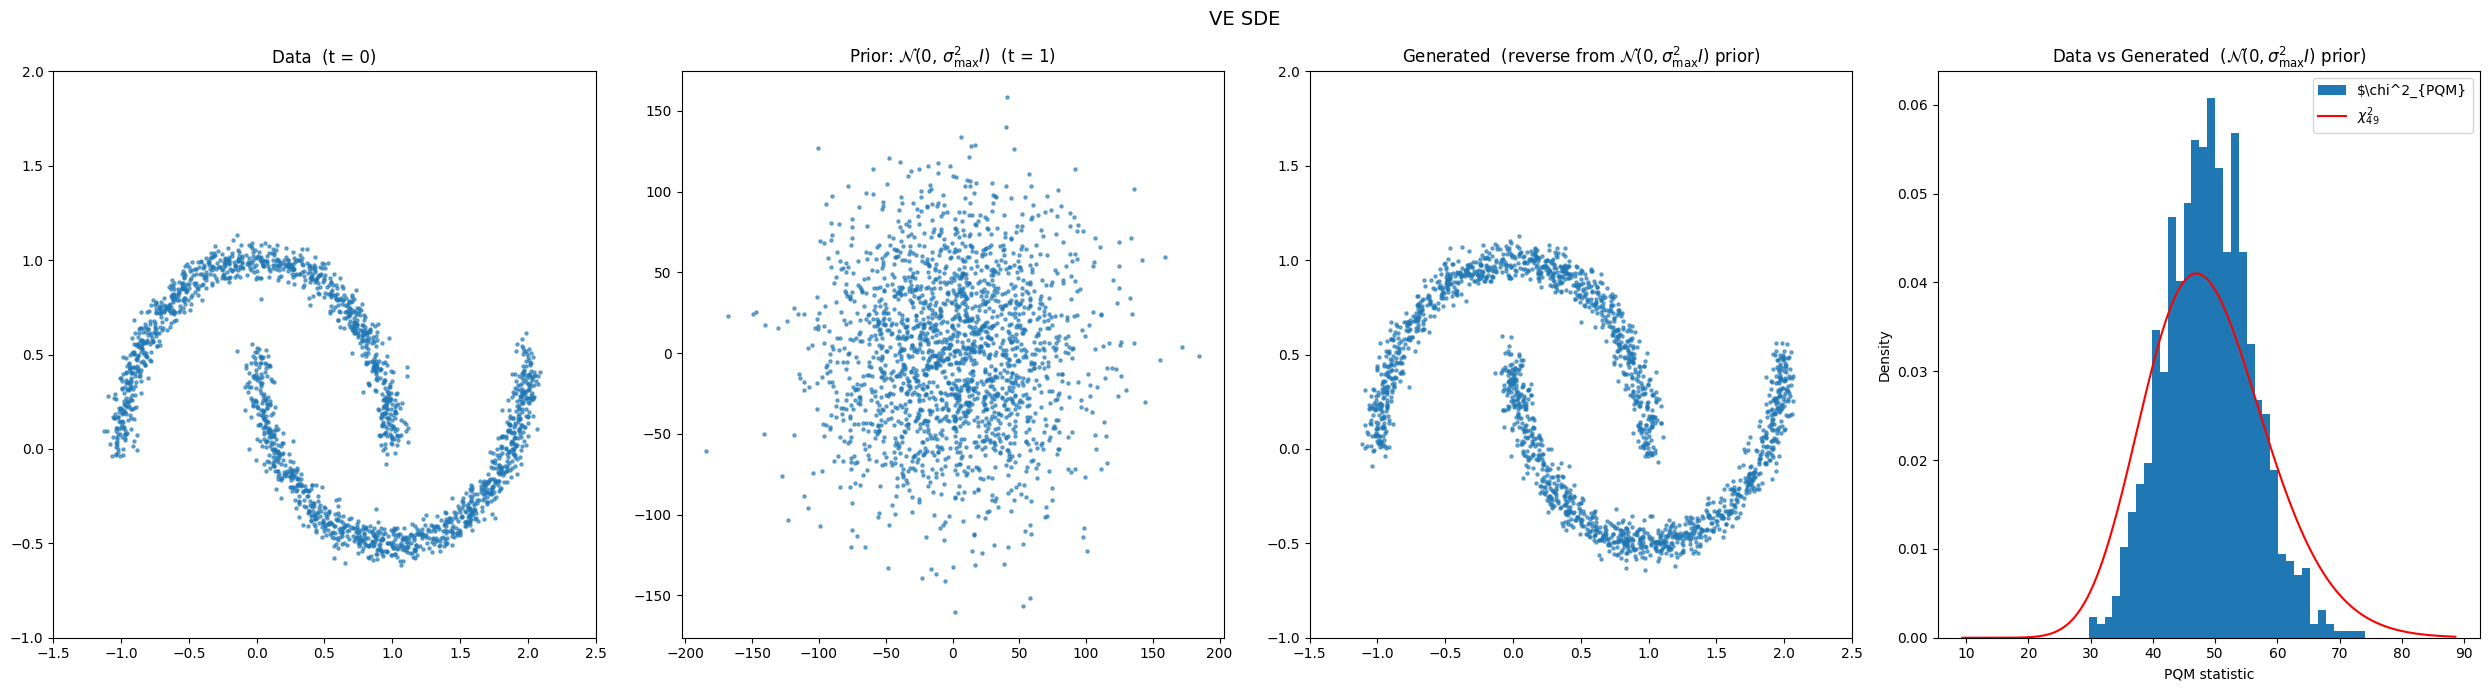

In [56]:
DATA_XLIM = (-1.5, 2.5)
DATA_YLIM = (-1.0, 2.0)

# fig, axes = plt.subplots(2, 4, figsize=(25, 10))
fig, axes = plt.subplots(1, 4, figsize=(25, 7))
zs_result_reverse_pass = run_pqm(samps, result_reverse_pass[0])

axes[0].scatter(samps[:, 0], samps[:, 1], s=5, alpha=0.6)
axes[0].set_title("Data  (t = 0)")
axes[0].set_xlim(*DATA_XLIM); axes[0].set_ylim(*DATA_YLIM)

axes[1].scatter(noisy_samples[:, 0], noisy_samples[:, 1], s=5, alpha=0.6)
axes[1].set_title(r"Prior: $\mathcal{N}(0,\,\sigma_{\max}^2 I)$  (t = 1)")

axes[2].scatter(result_reverse_pass[0][:, 0], result_reverse_pass[0][:, 1], s=5, alpha=0.6)
axes[2].set_title(r"Generated  (reverse from $\mathcal{N}(0,\sigma_{\max}^2 I)$ prior)")
axes[2].set_xlim(*DATA_XLIM); axes[2].set_ylim(*DATA_YLIM)

axes[3].hist(zs_result_reverse_pass, bins=35, density=True, label='$\chi^2_{PQM}')
axes[3].plot(ideal_chi2, chi2.pdf(ideal_chi2, df=49), color='red', label=r'$\chi^2_{49}$')
axes[3].set_xlabel('PQM statistic')
axes[3].set_ylabel('Density')
axes[3].set_title(r'Data vs Generated  ($\mathcal{N}(0,\sigma_{\max}^2 I)$ prior)')
axes[3].legend()

fig.suptitle("VE SDE", fontsize=14)
plt.tight_layout()
plt.show()